In [1]:
import pandas as pd


match = pd.read_csv('./data/gold_match.csv')


df_ohl = match.copy()

# Order by date
df_ohl = df_ohl.sort_values(by='match_date').reset_index(drop=True)

# victory 3 points, draw 1, defeat 0

def ohl_points(row):
    # if ohl played home
    if row['home_team'] == 'OH Leuven':
        if row['result_home'] == 'W': return 3
        elif row['result_home'] == 'D': return 1
        else: return 0
    # if played out
    else:
        if row['result_home'] == 'L': return 3
        elif row['result_home'] == 'D': return 1
        else: return 0

df_ohl['ohl_match_points'] = df_ohl.apply(ohl_points, axis=1)

#calculate the 3 previous game, without the first one
df_ohl['ohl_recent_form_points'] = df_ohl['ohl_match_points'].rolling(window=3).sum().shift(1)

# only home games
df_home_form = df_ohl[df_ohl['is_home_match'] == True][['match_id', 'match_date', 'away_team', 'tickets_scanned', 'ohl_recent_form_points']].copy()

# ignore the first games 
df_home_form['ohl_recent_form_points'] = df_home_form['ohl_recent_form_points'].fillna(4)

print("Sucess!")
print(df_home_form.head(10))

Sucess!
                     match_id  match_date             away_team  \
1   d256yo3eng04m0fu7b4sl7wno  2022-07-30              Westerlo   
3   d4mn5ksbxuvnaww4pmommxhqs  2022-08-14           Club Brugge   
5   d65hmi7sq03yzr5he1k7ypus4  2022-08-27           KV Oostende   
7   d80mkemezkz16bqh6lbn8tlhw  2022-09-10    Sporting Charleroi   
9   dak40etbhbqsr1nxyt50qcg0k  2022-10-01  Union Saint-Gilloise   
11  dcl81t8chgq07o8rw8orj5no4  2022-10-15                  Genk   
14  dfui3aovgvfccasonp6w5ajh0  2022-10-30                  Gent   
16  di0x0as1g324k0hoea1o5vvh0  2022-11-11               Seraing   
18  dkbsomyigazbberxvdmjq7wgk  2023-01-08              Kortrijk   
20  dmcif0n7veawzigj8cd5bm904  2023-01-17                 Eupen   

    tickets_scanned  ohl_recent_form_points  
1            5565.0                     4.0  
3            7440.0                     6.0  
5            4489.0                     3.0  
7            4508.0                     7.0  
9            6290.0     

In [2]:
# sort by recent points

# ascending false biiger to smaller
df_ordenado_pontos = df_home_form.sort_values(by='ohl_recent_form_points', ascending=False)

print("\n------ Top games by previous points -----")
print(df_ordenado_pontos[['match_date', 'away_team', 'ohl_recent_form_points', 'tickets_scanned']].head(20))


------ Top games by previous points -----
     match_date             away_team  ohl_recent_form_points  tickets_scanned
7    2022-09-10    Sporting Charleroi                     7.0           4508.0
35   2023-08-05                  RWDM                     7.0           7786.0
128  2025-11-23          Sint-Truiden                     7.0           5661.0
73   2024-05-25              Westerlo                     7.0           5907.0
42   2023-09-30        Standard Liège                     7.0           9211.0
29   2023-03-19            Anderlecht                     7.0          10827.0
3    2022-08-14           Club Brugge                     6.0           7440.0
121  2025-09-20      RAAL La Louvière                     6.0           4036.0
59   2024-02-17    Sporting Charleroi                     6.0           9228.0
33   2023-04-23        Standard Liège                     6.0          10079.0
138  2026-02-14                Dender                     5.0           5137.0
9    2022

In [3]:

# order by most sold tickets

df_ordenado_bilhetes = df_home_form.sort_values(by='tickets_scanned', ascending=False)

print("\n------- Top games: most tickets sold ---------")
print(df_ordenado_bilhetes[['match_date', 'away_team', 'tickets_scanned', 'ohl_recent_form_points']].head(15))


------- Top games: most tickets sold ---------
    match_date             away_team  tickets_scanned  ohl_recent_form_points
63  2024-03-17              Mechelen          11069.0                     1.0
29  2023-03-19            Anderlecht          10827.0                     7.0
54  2024-01-21            Anderlecht          10786.0                     3.0
89  2024-12-01            Anderlecht          10723.0                     2.0
48  2023-11-26           Club Brugge          10546.0                     0.0
86  2024-11-02           Club Brugge          10485.0                     4.0
33  2023-04-23        Standard Liège          10079.0                     6.0
61  2024-03-02  Union Saint-Gilloise           9789.0                     2.0
40  2023-09-17                  Gent           9598.0                     4.0
26  2023-02-26               Antwerp           9331.0                     1.0
46  2023-11-04              Westerlo           9240.0                     3.0
59  2024-02-17  

In [4]:
%run team_strength.ipynb

Team strength is based on 2 features:
- Win percentage
- Goal difference
The strength is normalized between 0 and 100

Only teams with 3 or more matches are included


In [5]:
# linear regression 

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import statsmodels.api as sm

# Load context data (calendar)
dfcontext = pd.read_csv('./data/gold_match_context.csv')

# Keep only relevant columns for the model
dfcontext = dfcontext[['match_id', 'is_weekend', 'is_midweek']]

# 1. DATA PREPARATION (Final Merge)
df_final = pd.merge(
    df_home_form, 
    final_table[['team', 'team_strength']], 
    left_on='away_team', 
    right_on='team', 
    how='inner'
).dropna(subset=['tickets_scanned', 'team_strength', 'ohl_recent_form_points'])

# Add weekend variable (context)
df_final = pd.merge(df_final, dfcontext[['match_id', 'is_weekend']], on='match_id', how='inner')
df_final['is_weekend'] = df_final['is_weekend'].astype(int)

# 2. DEFINE VARIABLES
X = df_final[['ohl_recent_form_points', 'team_strength', 'is_weekend']]
y = df_final['tickets_scanned']

# 3. TRAIN / TEST SPLIT (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# 4. MODEL PERFORMANCE METRICS
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)

print("======= MODEL PERFORMANCE REPORT =======")
print(f"MAE (Mean Absolute Error): {int(mae)} tickets")
print(f"RMSE (Penalty for Large Errors): {int(rmse)} tickets")
print(f"R² (Explained Variance): {r2:.2f}")
print(f"MAPE (Percentage Error): {mape:.2%}")
print("========================================\n")

# 5. STATISTICAL SIGNIFICANCE (P-VALUES)
X_stat = sm.add_constant(X)
statistical_summary = sm.OLS(y, X_stat).fit()

print("--- STATISTICAL SIGNIFICANCE ANALYSIS ---")
print(statistical_summary.pvalues)

======= MODEL PERFORMANCE REPORT =======
MAE (Mean Absolute Error): 1778 tickets
RMSE (Penalty for Large Errors): 2102 tickets
R² (Explained Variance): -0.14
MAPE (Percentage Error): 26.13%

--- STATISTICAL SIGNIFICANCE ANALYSIS ---
const                     7.646394e-10
ohl_recent_form_points    4.461266e-01
team_strength             5.389616e-02
is_weekend                2.027161e-01
dtype: float64


NameError: name 'previsoes_v3' is not defined

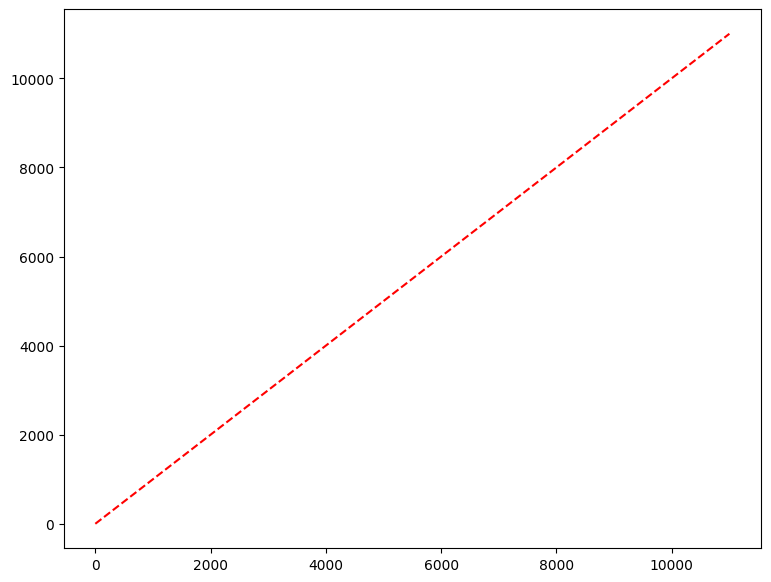

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Criar o gráfico
plt.figure(figsize=(9, 7))

# Criar a linha ideal (onde a previsão = realidade)
lims = [0, 11000]
plt.plot(lims, lims, color='red', linestyle='--', label='Perfect Prediction')

# Desenhar as nossas previsões
plt.scatter(y_test, previsoes_v3, alpha=0.6, color='blue', label='Our Model')

# Formatação profissional
plt.title('How Accurate is Our Model?', fontsize=15, fontweight='bold')
plt.xlabel('Actual Attendance (Tickets Scanned)', fontsize=12)
plt.ylabel('Predicted Attendance', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The scatter plot shows predictions are widely dispersed from the ideal line.")
print("This confirms the model has low predictive accuracy and weak explanatory power.")

In [ ]:
print("======= MODEL INTERPRETATION =======")
print("The model shows poor predictive performance.")
print("R² = -0.14 -> The model performs worse than using a simple average baseline.")
print("MAPE = 26% -> Prediction error is too high for practical use.")
print("====================================\n")

print("======= STATISTICAL SIGNIFICANCE =======")
print("ohl_recent_form_points -> NOT significant (p = 0.446)")
print("team_strength -> borderline significance (p = 0.053)")
print("is_weekend -> NOT significant (p = 0.203)")
print("========================================\n")

print("======= KEY INSIGHT =======")
print("The selected variables do not explain ticket attendance.")
print("There is no strong statistical relationship between features and target.")
print("================================\n")

print("======= CONCLUSION =======")
print("This approach is not suitable in its current form.")
print("The issue is not the model, but the lack of relevant features.")
print("Better explanatory variables are required to improve performance.")
print("================================")

======= MODEL INTERPRETATION =======
The model shows poor predictive performance.
R² = -0.14 -> The model performs worse than using a simple average baseline.
MAPE = 26% -> Prediction error is too high for practical use.

======= STATISTICAL SIGNIFICANCE =======
ohl_recent_form_points -> NOT significant (p = 0.446)
team_strength -> borderline significance (p = 0.053)
is_weekend -> NOT significant (p = 0.203)

======= KEY INSIGHT =======
The selected variables do not explain ticket attendance.
There is no strong statistical relationship between features and target.

======= CONCLUSION =======
This approach is not suitable in its current form.
The issue is not the model, but the lack of relevant features.
Better explanatory variables are required to improve performance.
